# Portfolio Project: Document Difficulty Classification Model
This notebook implements a scratch-built **Logistic Regression** pipeline to classify whether a document's layout and formatting difficulty is **Easy (0)** or **Hard (1)**.

By analyzing structural metrics—**Word Count, Average Sentence Length, Sentence Complexity %, and Technical Terms %**—the model applies a Sigmoid activation function to map custom weights into clear probabilities, helping language service providers automate project triaging.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from utils import zscore_normalize_features, gradient_descent_classification

In [3]:
# Loading the dataset
df = pd.read_csv('translation_data.csv')

# Defining our 4 structural features
feature_cols = ['words', 'avg_sentence_length', 'sentence_complexity_pct', 'technical_terms_pct']

# Extracting features (X) and classification target (y)
X = df[feature_cols].values
y = df['difficulty'].values

print("--- Dataset Classification Target Check ---")
print(f"Feature Matrix Shape (X): {X.shape}")
print(f"Target Vector Shape (y):  {y.shape}")
print(f"Class distribution: Easy Documents (0) = {np.sum(y==0)}, Hard Documents (1) = {np.sum(y==1)}")

--- Dataset Classification Target Check ---
Feature Matrix Shape (X): (15, 4)
Target Vector Shape (y):  (15,)
Class distribution: Easy Documents (0) = 5, Hard Documents (1) = 10


In [4]:
# Normalizing features to stabilize logistic gradient descent
X_norm, X_mu, X_sigma = zscore_normalize_features(X)

print("--- Normalization Summary ---")
print(f"First normalized row snippet:\n{X_norm[0]}\n")
print(f"Feature Means (mu):          {X_mu}")
print(f"Feature Deviations (sigma):  {X_sigma}")

--- Normalization Summary ---
First normalized row snippet:
[-1.62018517 -1.7024217  -1.66371589 -1.5555069 ]

Feature Means (mu):          [4500.           21.13333333   44.73333333   29.8       ]
Feature Deviations (sigma):  [2160.24689947    5.36490654   17.8716411    12.72896958]


In [5]:
# Initializing parameters: 4 weights (one for each feature) and 1 bias scalar
w_init = np.zeros(X_norm.shape[1])
b_init = 0.0

# Hyperparameters
alpha = 0.3
iterations = 1000

# Training the model using the classification engine from utils.py
w_final, b_final, J_hist = gradient_descent_classification(X_norm, y, w_init, b_init, alpha, iterations)

print("=== Optimized Classification Parameters ===")
print(f"Final Weights Vector (w_final): {w_final}")
print(f"Final Bias Scalar (b_final):    {b_final:.4f}\n")

# Mapping weights back to their feature names for recruiter readability
for col, weight in zip(feature_cols, w_final):
    print(f"Weight impact for '{col}': {weight:+.4f}")

Classification Iteration    0: Cost = 0.5275
Classification Iteration  100: Cost = 0.1048
Classification Iteration  200: Cost = 0.0766
Classification Iteration  300: Cost = 0.0631
Classification Iteration  400: Cost = 0.0548
Classification Iteration  500: Cost = 0.0489
Classification Iteration  600: Cost = 0.0445
Classification Iteration  700: Cost = 0.0410
Classification Iteration  800: Cost = 0.0381
Classification Iteration  900: Cost = 0.0357
=== Optimized Classification Parameters ===
Final Weights Vector (w_final): [1.68125847 2.51104245 2.6038787  2.27341483]
Final Bias Scalar (b_final):    4.9852

Weight impact for 'words': +1.6813
Weight impact for 'avg_sentence_length': +2.5110
Weight impact for 'sentence_complexity_pct': +2.6039
Weight impact for 'technical_terms_pct': +2.2734


# Model Evaluation & Performance Metrics
Because Logistic Regression outputs raw probabilities between `0.0` and `1.0`, we apply a standard classification threshold of **0.5**. 
* If probability $\ge 0.5 \rightarrow$ Class 1 (Hard Layout)
* If probability $< 0.5 \rightarrow$ Class 0 (Easy Layout)

Below, we compute predictions, calculate the overall accuracy score, and look at the final loss curve.

In [6]:
from utils import sigmoid

# 1. Compute raw probability scores for all rows
probabilities = sigmoid(X_norm @ w_final + b_final)

# 2. Convert probabilities to binary predictions using a 0.5 threshold
predictions = (probabilities >= 0.5).astype(int)

# 3. Calculate accuracy percentage
accuracy = np.mean(predictions == y) * 100

print(f"CLASSIFICATION MODEL EVALUATION")
print(f"Training Accuracy Score: {accuracy:.1f}%\n")

# Print a structured evaluation dashboard table
print(f"{'Actual Class':<14} | {'Predicted Probability':<23} | {'Predicted Class':<15}")
print("-" * 58)

for i in range(len(y)):
    print(f"{y[i]:<14} | {probabilities[i]*100:<21.1f}% | {predictions[i]:<15}")

CLASSIFICATION MODEL EVALUATION
Training Accuracy Score: 100.0%

Actual Class   | Predicted Probability   | Predicted Class
----------------------------------------------------------
0              | 0.0                  % | 0              
0              | 0.1                  % | 0              
0              | 0.3                  % | 0              
0              | 2.9                  % | 0              
0              | 15.2                 % | 0              
1              | 76.7                 % | 1              
1              | 96.6                 % | 1              
1              | 99.3                 % | 1              
1              | 99.9                 % | 1              
1              | 100.0                % | 1              
1              | 100.0                % | 1              
1              | 100.0                % | 1              
1              | 100.0                % | 1              
1              | 100.0                % | 1              
1    

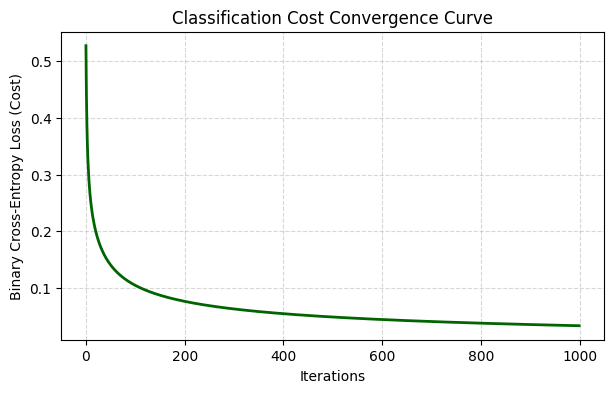

In [7]:
plt.figure(figsize=(7, 4))
plt.plot(range(len(J_hist)), J_hist, color='darkgreen', linewidth=2)
plt.title("Classification Cost Convergence Curve")
plt.xlabel("Iterations")
plt.ylabel("Binary Cross-Entropy Loss (Cost)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()